# WPLSC (within-participants PLSC)

Regular PLSC captures multivariate patterns of association when the unit of observation is a participant (or a participant average for a within-participants condition). However, we often want to examine associations within participants, where the unit of observation is a single trial. To do this we can use a within-participants variant of PLSC ([Roberts et al., 2016](https://doi.org/10.1016/j.neuroimage.2016.04.028), which is implemented in `pyplsc` in the `WPLSC` class. Briefly, the method is to compute cross-correlation matrices within participants, average these matrices across participants, and apply singular value decomposition to the average matrices.

## Setting up simulated data

We'll simulate data with 10 participants, in which a single latent variable explains the relatinoship between a set of 50 observed variables in the data array and a set of 4 covariates. The latent variable will have a sinusoidal pattern of loadings onto the observed variables, and positive loadings onto all of the covariates. First, we will import the necessary libraries and seed the random number generator for reproducibility:

In [1]:
import numpy as np
import pandas as pd
from pyplsc import WPLSC
from matplotlib import pyplot as plt

np.random.seed(123)

Next, we will create a set of sinusoidal loadings from the latent variable onto the 50 observed variables. Importantly, these loadings are shared by all the participants---between-participants variation in loadings is not explicitly modeled:

In [2]:
n_var = 50
data_loadings = np.sin(0.2*np.arange(n_var)).reshape(1, n_var) # Sinusoidal loading pattern

Next, for each participant, we'll simulate a normally distributed latent variable, compute the data array as the latent variable multiplied by the loadings plus noise, and compute each covariate as simply## Fitting and evaluating the model

Since the data are not stratified by any experimental condition, we can fit the model by simply providing the data array and the covariates withut a design matrix specifying conditions: the latent variable plus noise.

In [3]:
n_subj = 10
n_trials = 40
n_cov = 4
subjwise_data = []
subjwise_covs = []
for subj in range(n_subj):
    # Simulate latent variable
    latent_var = np.random.normal(size=(n_trials, 1))
    # Simulate data array
    data_noise = 0.5*np.random.normal(size=(n_trials, n_var))
    data = latent_var @ data_loadings + data_noise
    subjwise_data.append(data)
    # Simulate covariates
    cov_noise = np.random.normal(size=(n_trials, n_cov))
    covariates = latent_var + cov_noise # Effectively all loadings of 1
    covariates = pd.DataFrame(covariates, columns=['Cov. %s' % cov for cov in range(1, n_cov + 1)])
    subjwise_covs.append(covariates)

## Fitting and evaluating the model

To fit the model, we simply provide the lists of participant-wise data arrays and covariate arrays to `WPLSC.fit()`:

In [4]:
mod = WPLSC()
mod.fit(data=subjwise_data, covariates=subjwise_covs)

We can use permutation testing to evaluate the significance of the latent variables identified by the model. This yields one $p$ value per singular value:

In [5]:
mod.permute(1000, return_null_dist=False)
print(mod.pvals_)
is_sig = mod.pvals_ < 0.05
sig_lvs = np.where(is_sig)[0]
print(sig_lvs)

Permuting: 100%|██████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 355.13it/s]

[0.000999   0.82317682 0.44355644 0.10689311]
[0]


Thus there is one significant pair of latent variables, in line with how we simulated the data. Next, we can perform bootstrap resampling to assess the reliability of the data saliences and to evaluate how reliably the design scores correlate with each covariate.

In [7]:
mod.bootstrap(1000, return_boot_stat_dist=False)

Resampling: 100%|█████████████████████████████████████████████████████████████████| 1000/1000 [00:07<00:00, 139.28it/s]


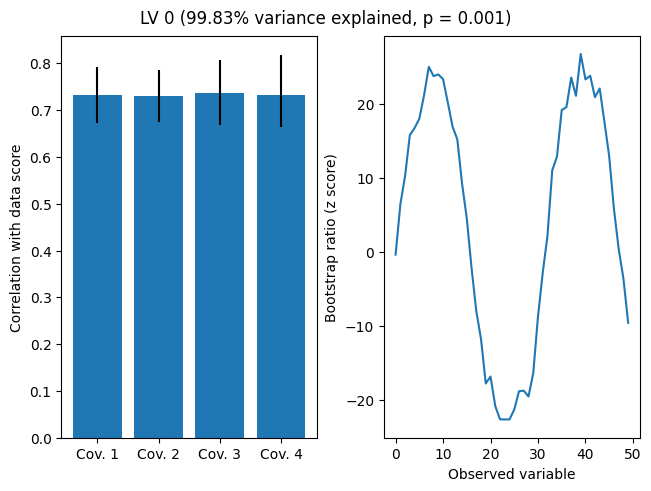

In [11]:
labels = mod.design_sal_labels_['covariate']
n_sig = len(sig_lvs)

fig = plt.figure(constrained_layout=True)
subfigs = fig.subfigures(nrows=n_sig)
if n_sig == 1:
    subfigs = [subfigs]

for plot_idx, lv_idx in enumerate(sig_lvs):
    subfig = subfigs[plot_idx]
    subfig.suptitle('LV %s (%.2f%% variance explained, p = %.3f)' % (
        lv_idx,
        100*mod.variance_explained_[lv_idx],
        mod.pvals_[lv_idx]))
    ax = subfig.subplots(ncols=2)
    ax[0].bar(x=labels,
              height=mod.boot_stat_val_[:, lv_idx],
              yerr=mod.get_boot_stat_yerr(lv_idx))
    ax[0].set_ylabel('Correlation with data score')
    ax[1].plot(mod.data_sals_z_[:, lv_idx])
    ax[1].set_ylabel('Bootstrap ratio (z score)')
    ax[1].set_xlabel('Observed variable')


As we can see, the model recovers the roughly sinusoidal pattern of loadings. `mod.flip_signs(lv_idx=0)` can be used to obtain an equivalent solution in which the covariates have positive correlations with the latent variable.